<center><font size=8>Project: Machine Learning: Personal Loan Campaign</font></center>

# 1. Define the problem and perform an Exploratory Data Analysis

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.



## **Objectives**

 As a Data Scientist at AllLife Bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

# **Installing and Importing the necessary libraries**

In [44]:
!pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 -q
!pip install "sqlalchemy-mate==1.4.28.4"
!pip install "uszipcode==0.2.6"


In [45]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split the data into train and test sets
from sklearn.model_selection import train_test_split


# to check a regression model's performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc
from sklearn import metrics
from sklearn.preprocessing import StandardScaler



# To build model for prediction
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report
)

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# Zip Code
from uszipcode import SearchEngine
search = SearchEngine(simple_zipcode=True)



# **Loading the data**

In [46]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
# loading data into a pandas dataframe
file_path = '/content/drive/My Drive/PGD-AIML/Assignments/Linear-Regression/Loan_Modelling.csv'
df = pd.read_csv(file_path)

# creating a copy of the data
data= df.copy()

# **Data Overview**

## **Checking the first 5 rows**

In [48]:
data.head(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


## **Checking the shape of the data**



In [49]:
data.shape

(5000, 14)

* The dataset has 5000 rows and 14 columns. So it will be 13 features for 1 target



## **Checking the attribute types**

In [50]:
data.dtypes

,0
ID,int64
Age,int64
Experience,int64
Income,int64
ZIPCode,int64
Family,int64
CCAvg,float64
Education,int64
Mortgage,int64
Personal_Loan,int64


* All the columns in the dataset are integers, except Credit Rating column(CCAvg)

## **Checking the for null**

In [51]:
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


There is no null values present in the dataset

## **Checking for missing values**

In [52]:
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


* There are no missing values in the data

## Univariate Analysis

## **Checking for duplicate values**

In [53]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data

In [54]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [55]:
#Categorize the columns for analysis
numerical_cols = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']
categorical_cols = ['Family', 'Education']
binary_cols = ['Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Personal_Loan']
id_cols = ['ID']

 Numerical variables analysis

Variable: Age
count    5000.000000
mean       45.338400
std        11.463166
min        23.000000
25%        35.000000
50%        45.000000
75%        55.000000
max        67.000000
Name: Age, dtype: float64
Skewness: -0.02934068151284029
----------------------------------------




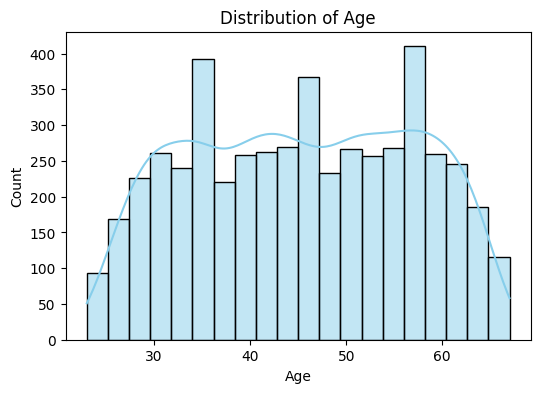

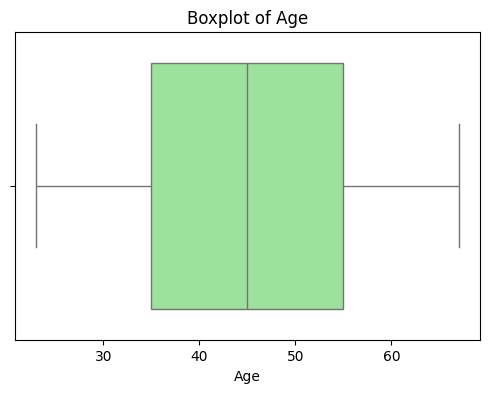

Variable: Experience
count    5000.000000
mean       20.104600
std        11.467954
min        -3.000000
25%        10.000000
50%        20.000000
75%        30.000000
max        43.000000
Name: Experience, dtype: float64
Skewness: -0.026324688402384513
----------------------------------------




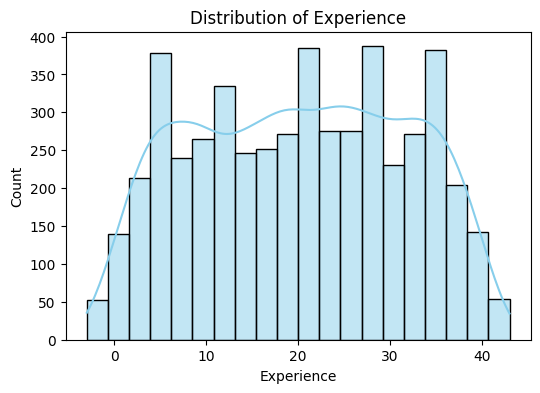

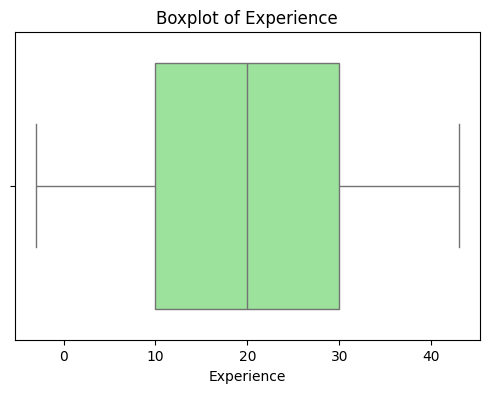

Variable: Income
count    5000.000000
mean       73.774200
std        46.033729
min         8.000000
25%        39.000000
50%        64.000000
75%        98.000000
max       224.000000
Name: Income, dtype: float64
Skewness: 0.8413386072610816
----------------------------------------




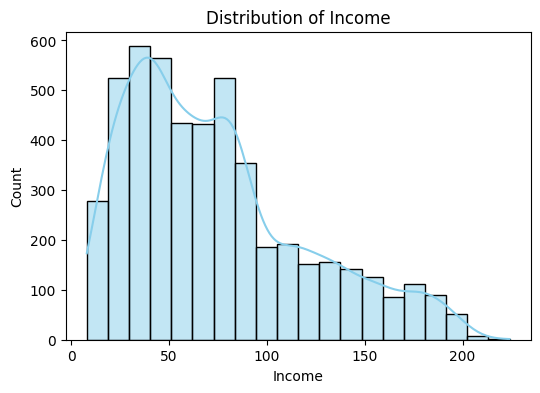

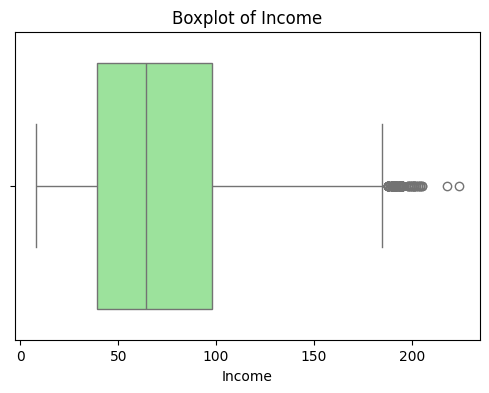

Variable: CCAvg
count    5000.000000
mean        1.937938
std         1.747659
min         0.000000
25%         0.700000
50%         1.500000
75%         2.500000
max        10.000000
Name: CCAvg, dtype: float64
Skewness: 1.5984433366678663
----------------------------------------




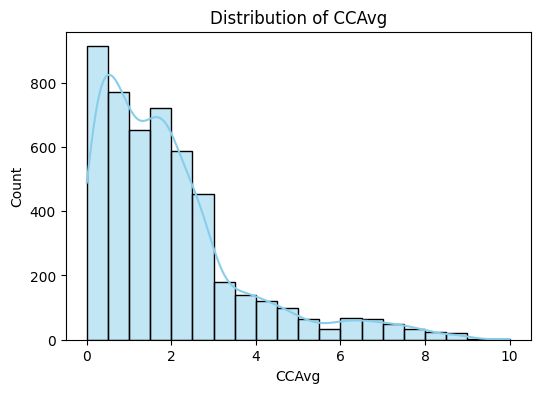

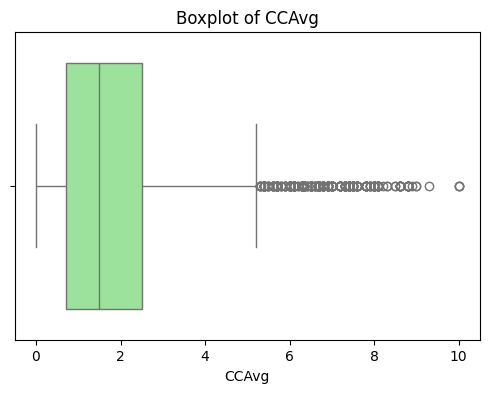

Variable: Mortgage
count    5000.000000
mean       56.498800
std       101.713802
min         0.000000
25%         0.000000
50%         0.000000
75%       101.000000
max       635.000000
Name: Mortgage, dtype: float64
Skewness: 2.1040023191079444
----------------------------------------




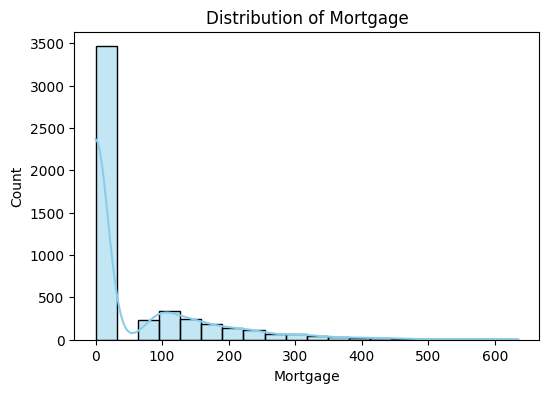

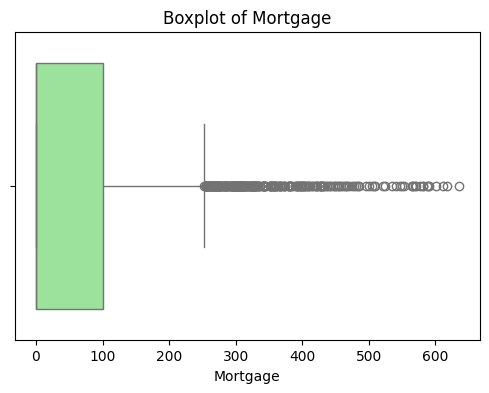

In [56]:
for col in numerical_cols:
    print(f"Variable: {col}")
    print(df[col].describe())
    print(f"Skewness: {df[col].skew()}")
    print("-"*40)

    print("\n")
    # Histogram
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

    print("\n")

    # Boxplot
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.show()

Categorical columns Analysis

Variable: Family
Family
1    1472
2    1296
4    1222
3    1010
Name: count, dtype: int64
----------------------------------------


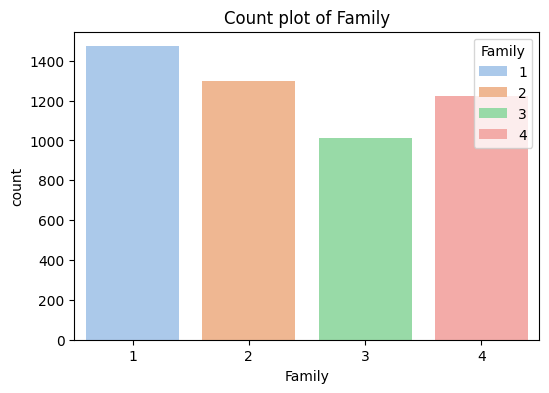

Variable: Education
Education
1    2096
3    1501
2    1403
Name: count, dtype: int64
----------------------------------------


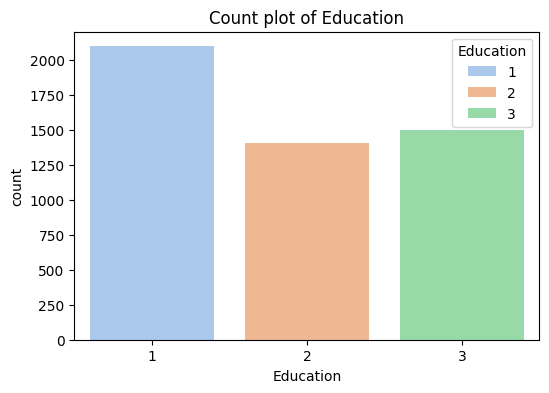

In [57]:
for col in categorical_cols:
    print(f"Variable: {col}")
    print(df[col].value_counts())
    print("-"*40)

    # Count plot
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], hue=df[col] ,data=df, palette='pastel')
    plt.title(f'Count plot of {col}')
    plt.show()

Binary variables analysis

Variable: Securities_Account
Securities_Account
0    4478
1     522
Name: count, dtype: int64
----------------------------------------


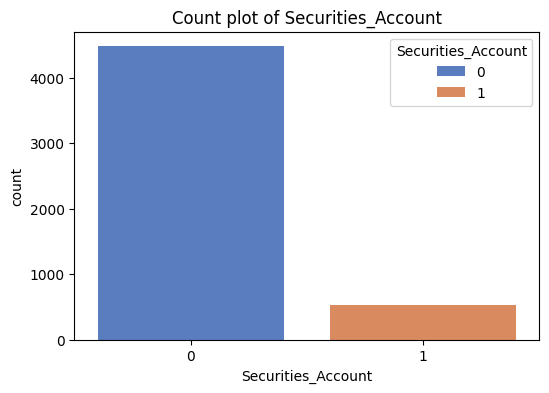

Variable: CD_Account
CD_Account
0    4698
1     302
Name: count, dtype: int64
----------------------------------------


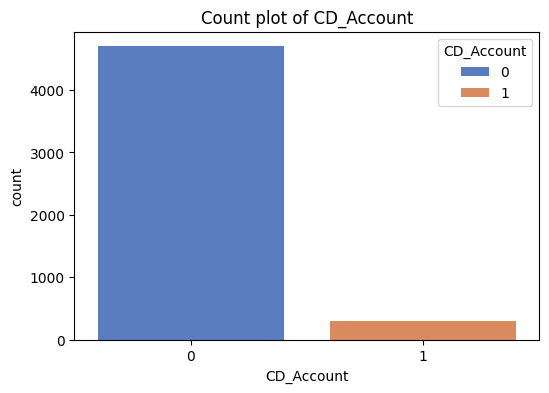

Variable: Online
Online
1    2984
0    2016
Name: count, dtype: int64
----------------------------------------


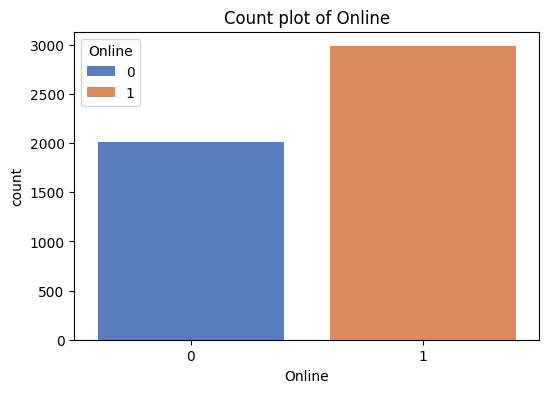

Variable: CreditCard
CreditCard
0    3530
1    1470
Name: count, dtype: int64
----------------------------------------


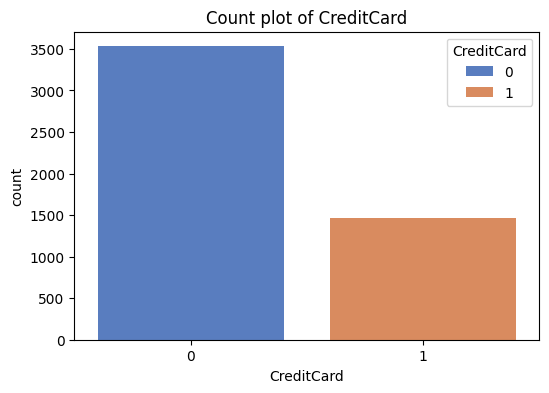

Variable: Personal_Loan
Personal_Loan
0    4520
1     480
Name: count, dtype: int64
----------------------------------------


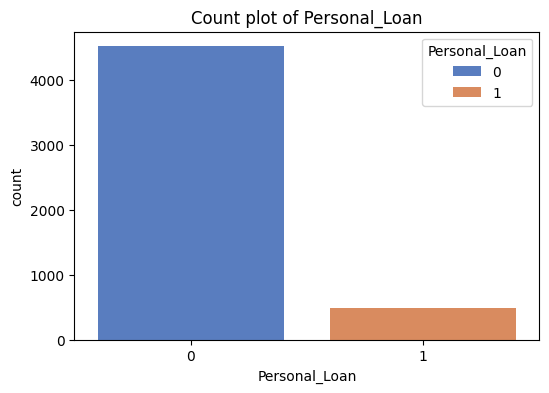

In [58]:
for col in binary_cols:
    print(f"Variable: {col}")
    print(df[col].value_counts())
    print("-"*40)

    # Count plot
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], hue=df[col], data=df, palette='muted')
    plt.title(f'Count plot of {col}')
    plt.show()

In [59]:
if 'Experience' in df.columns:
    neg_exp = df[df['Experience'] < 0]
    print(f"\nNumber of rows with negative Experience: {len(neg_exp)}")
    if len(neg_exp) > 0:
        print(neg_exp[['ID', 'Age', 'Experience']])


Number of rows with negative Experience: 52
        ID  Age  Experience
89      90   25          -1
226    227   24          -1
315    316   24          -2
451    452   28          -2
524    525   24          -1
536    537   25          -1
540    541   25          -1
576    577   25          -1
583    584   24          -1
597    598   24          -2
649    650   25          -1
670    671   23          -1
686    687   24          -1
793    794   24          -2
889    890   24          -2
909    910   23          -1
1173  1174   24          -1
1428  1429   25          -1
1522  1523   25          -1
1905  1906   25          -1
2102  2103   25          -1
2430  2431   23          -1
2466  2467   24          -2
2545  2546   25          -1
2618  2619   23          -3
2717  2718   23          -2
2848  2849   24          -1
2876  2877   24          -2
2962  2963   23          -2
2980  2981   25          -1
3076  3077   29          -1
3130  3131   23          -2
3157  3158   23          -1
327

Univariate Analysis Observations

1.   Experience have nagative values. We have to check the values and replace the valid values by imputation strategy to fix the issues
2.   The distrubution for Income is right skewed. This means that we have few customers earning more than the median income of 98K USD. We observe outliers in this columns that need: to be checked or treated
3. There are outliers on higher side for Income, CC Avg and Mortgage features
4. From the box plot, Family distibution looks right skewed pattern
  Majority of the customers have family size of 1. This could infer that unmarried customers consitute the majority.
5. The distribution of age column is normal with negligible right skewness.
6. There are 52 negative experience values found, which are not correct. this has to be trated on Data pre-processing Stage
7. Family Size 1 customers shows more loan accepted, this may indicate the bachelors and young people availing the loan
8. The distribution for education is slightly skewed to the right
9. Mortgage distribution seems to be heavily skewed to the right and we observe many outliers in this columns and calls for furher investigation
10. Only 9.6% of the customers accepted personal loan offered during the last campaign
11. Nearly 90% of the customers have not accepted personal loans.
We can build a model that will help us to identify customers who can accept the facility.

## Bi-Variate Analysis

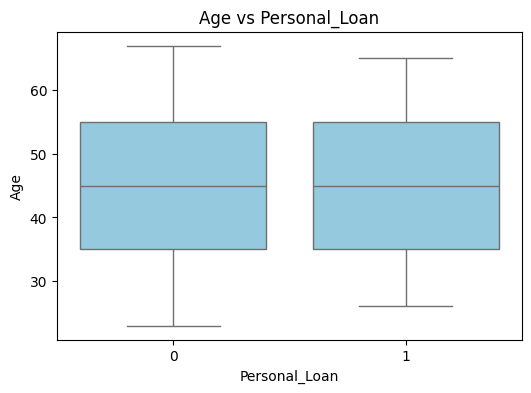

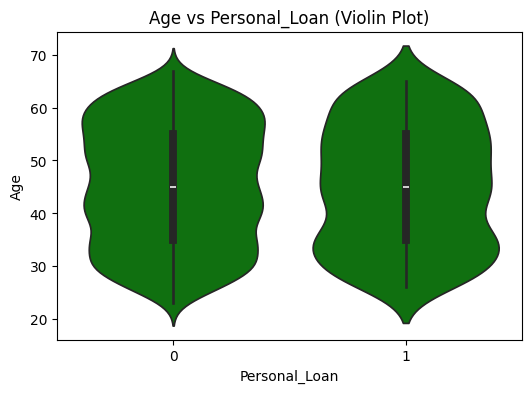

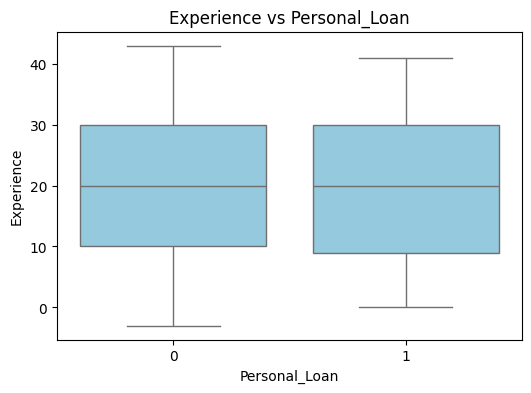

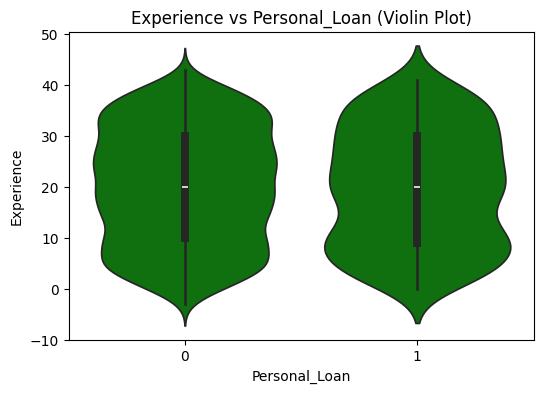

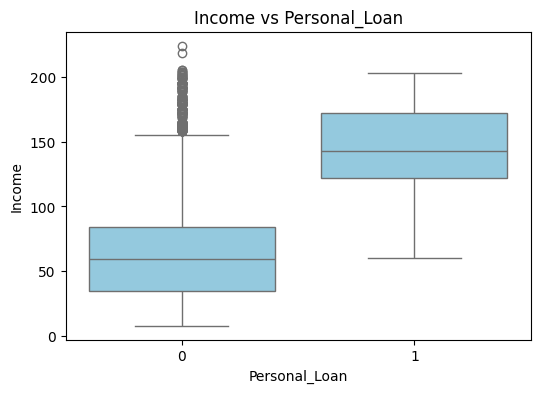

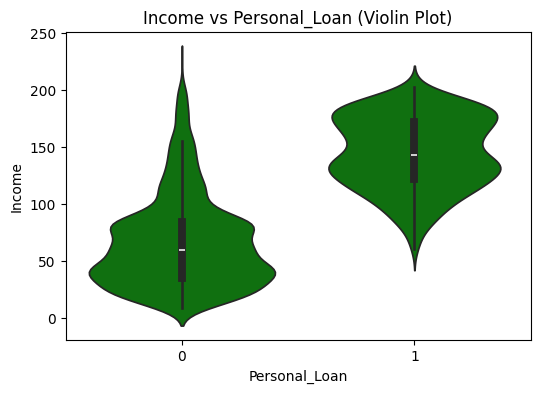

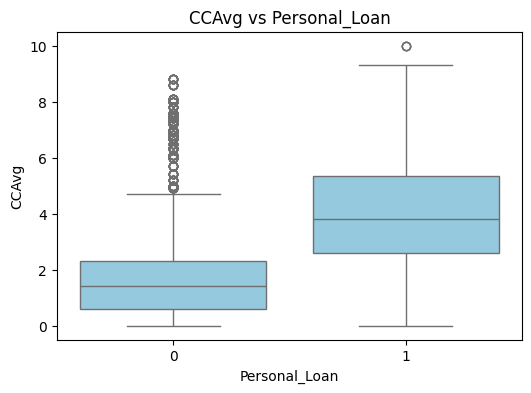

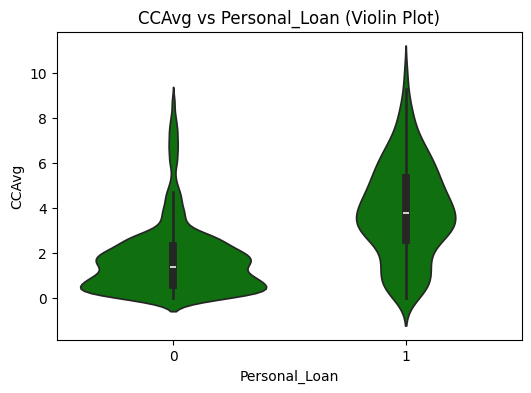

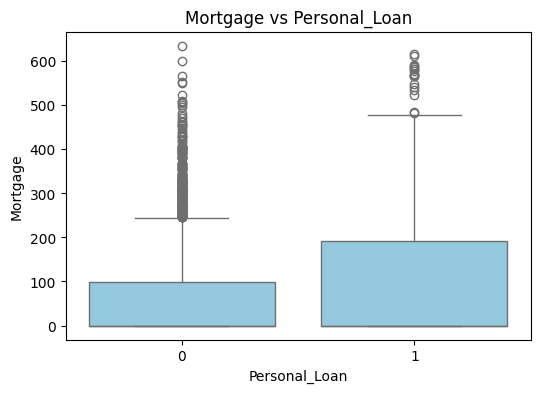

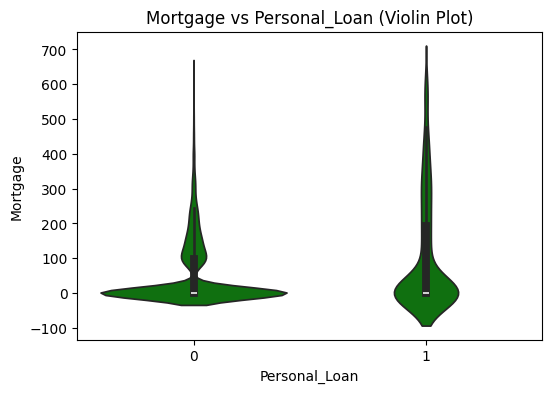

In [60]:
for col in numerical_cols:
    print('\n')
    print('\n')
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Personal_Loan', y=col, data=df,  color='skyblue')
    plt.title(f'{col} vs Personal_Loan')
    plt.show()

    print('\n')
    plt.figure(figsize=(6,4))
    sns.violinplot(x='Personal_Loan', y=col, data=df,  color='green')
    plt.title(f'{col} vs Personal_Loan (Violin Plot)')
    plt.show()

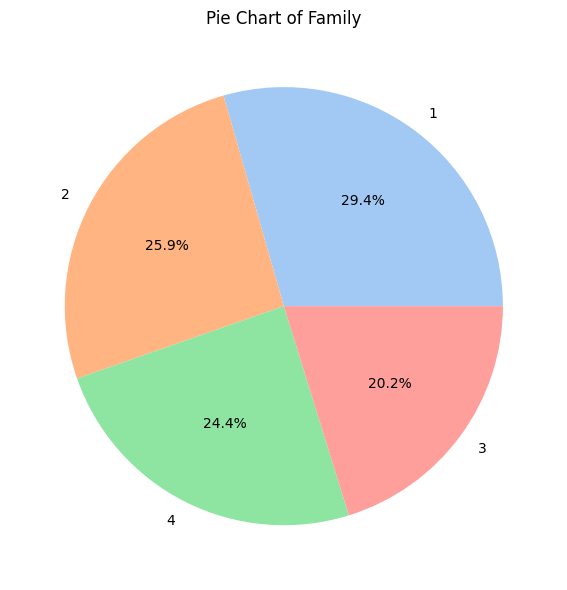

<Figure size 640x480 with 0 Axes>

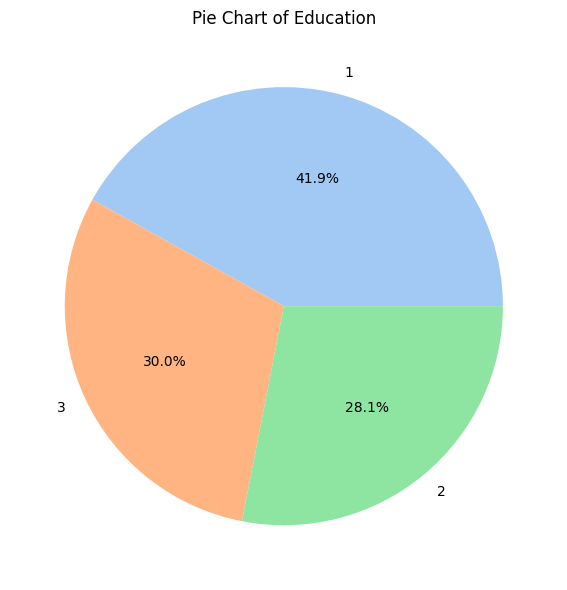

<Figure size 640x480 with 0 Axes>

In [61]:
# categorical_cols = ['Online','CreditCard']


for col in categorical_cols:
    plt.figure(figsize=(6,6))
    counts = data[col].value_counts()

    plt.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=sns.color_palette("pastel")
    )
    plt.title(f"Pie Chart of {col}")
    plt.tight_layout()   # ← adds spacing around the plot
    plt.ylabel("")
    plt.show()
    plt.subplots_adjust(wspace=0.4)  # ← add horizontal space







1.   Approximately 60% of the bank's customers use internet banking facilities offered by the bank, while 40% do not use the facility
2.   Only 29% of customers use credit card facilities by other banks






In [62]:
sns.pairplot(data)

Output hidden; open in https://colab.research.google.com to view.

In [63]:
def distribution_plot_wrt_target(data, feature, target):
    plt.subplots_adjust(wspace=2)  # ← add horizontal space

    plt.figure(figsize=(8,5))
    sns.histplot(
        data=data,
        x=feature,
        hue=target,
        kde=True,
        bins=30,
        palette="Set2",
        alpha=0.6
    )
    plt.title(f"Distribution of {feature} with respect to {target}")

    plt.show()

<Figure size 640x480 with 0 Axes>

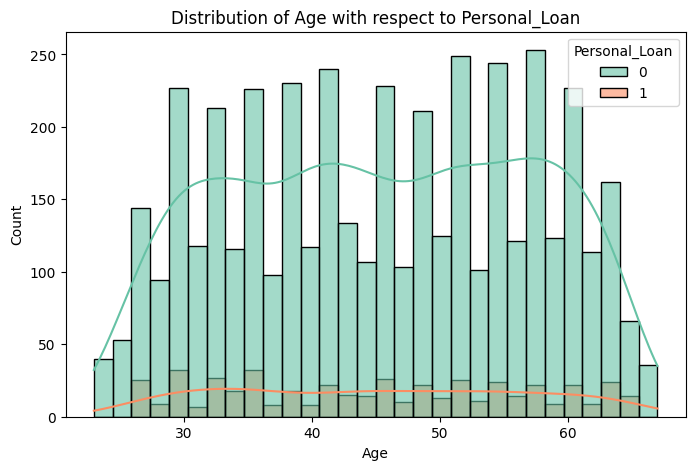

<Figure size 640x480 with 0 Axes>

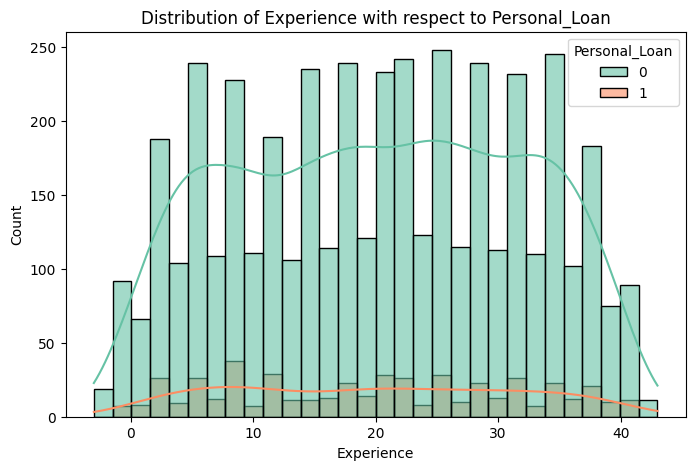

<Figure size 640x480 with 0 Axes>

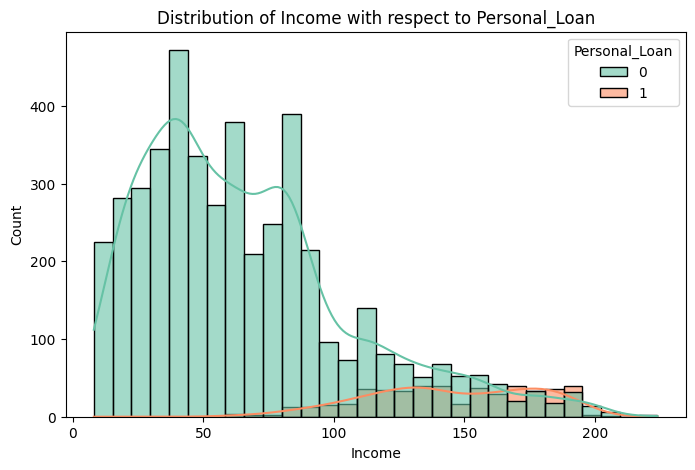

<Figure size 640x480 with 0 Axes>

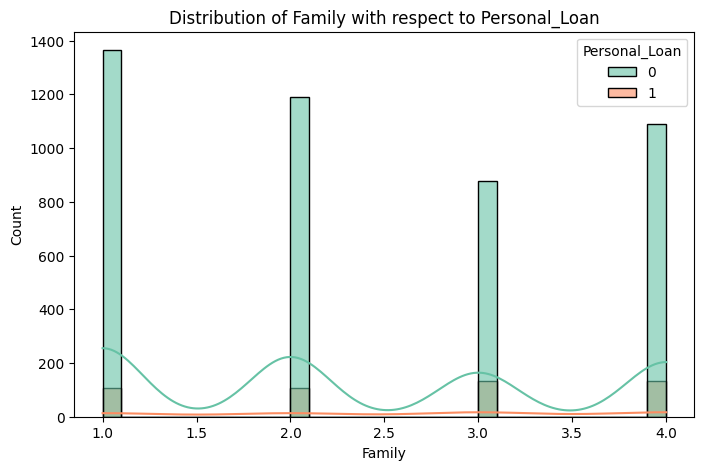

<Figure size 640x480 with 0 Axes>

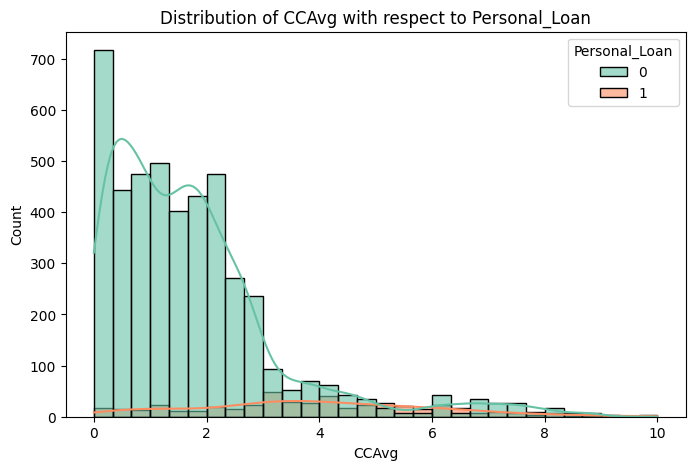

<Figure size 640x480 with 0 Axes>

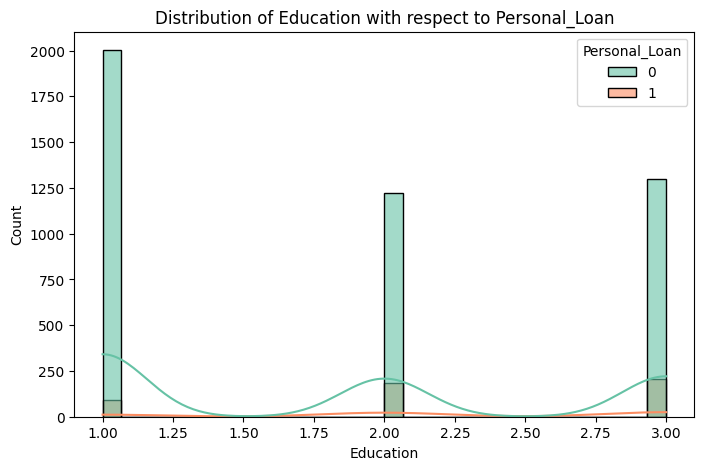

<Figure size 640x480 with 0 Axes>

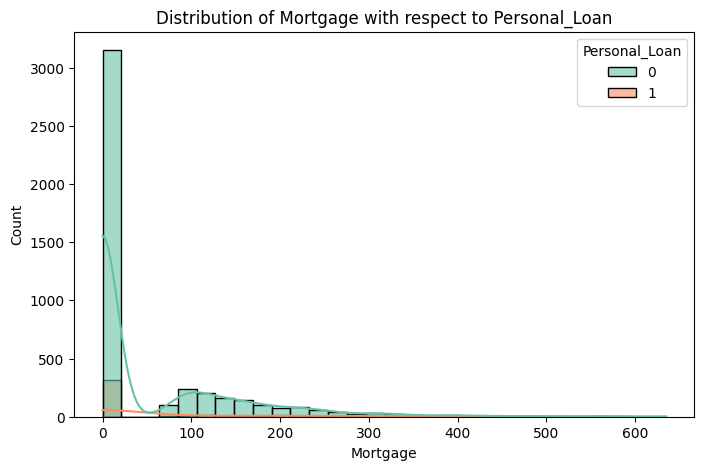

<Figure size 640x480 with 0 Axes>

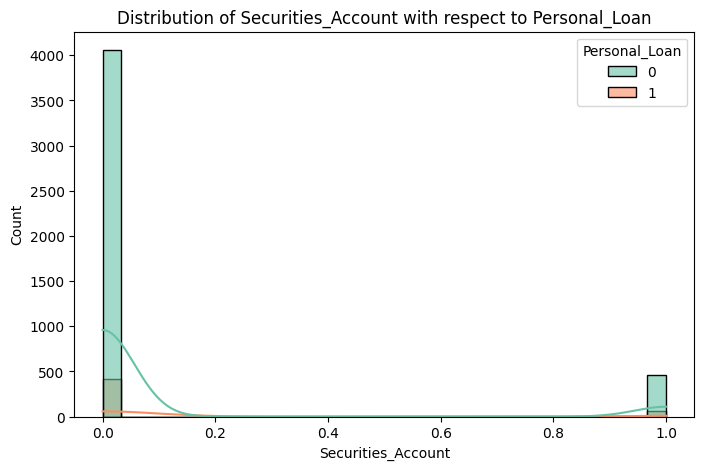

<Figure size 640x480 with 0 Axes>

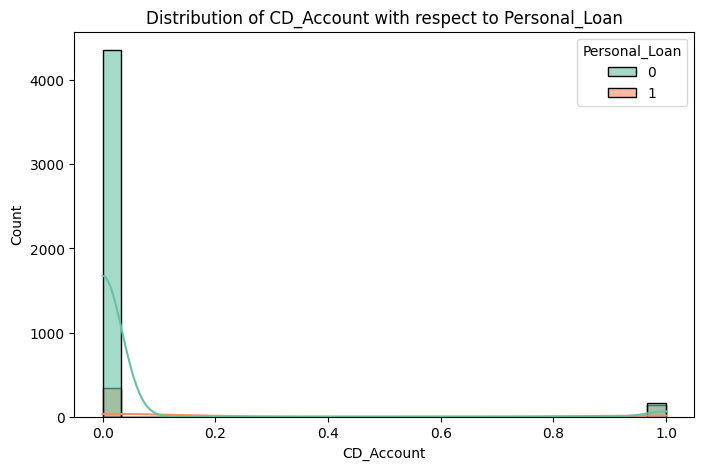

<Figure size 640x480 with 0 Axes>

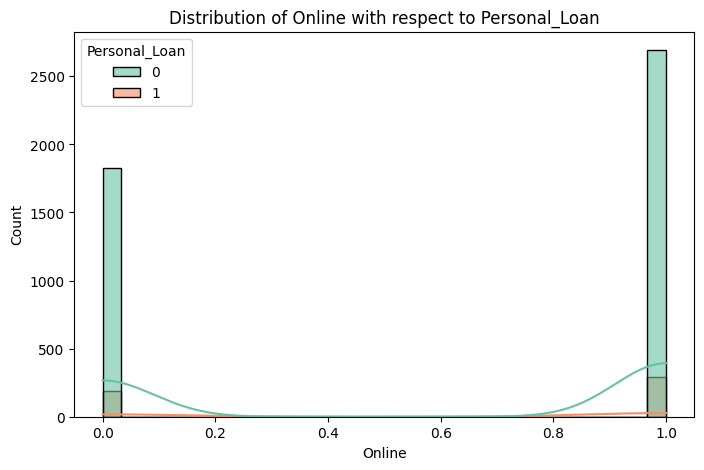

<Figure size 640x480 with 0 Axes>

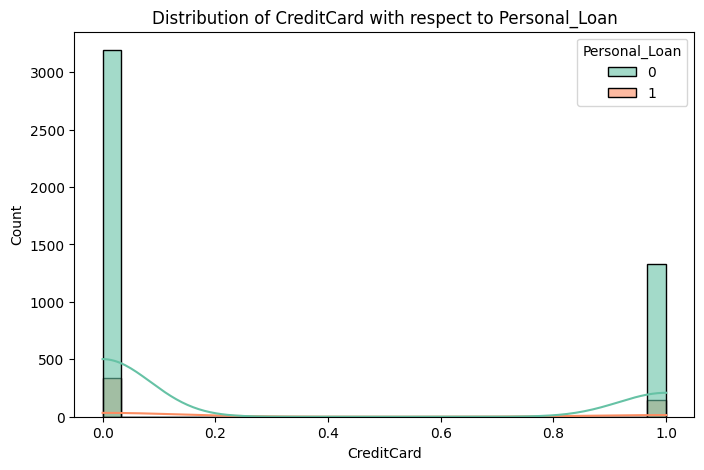

In [64]:
valid_options = ["ZIPCode", "Personal_Loan", "ID", "Region"] ## Removing Zip code & target from loop
for column in data.columns:
    if column not in valid_options:
        distribution_plot_wrt_target(data,column, "Personal_Loan")



*  Customers with uptp 100K Income range availing the Personal loans than other income groups
*   customers with Mortage, not opting for personal loans




In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


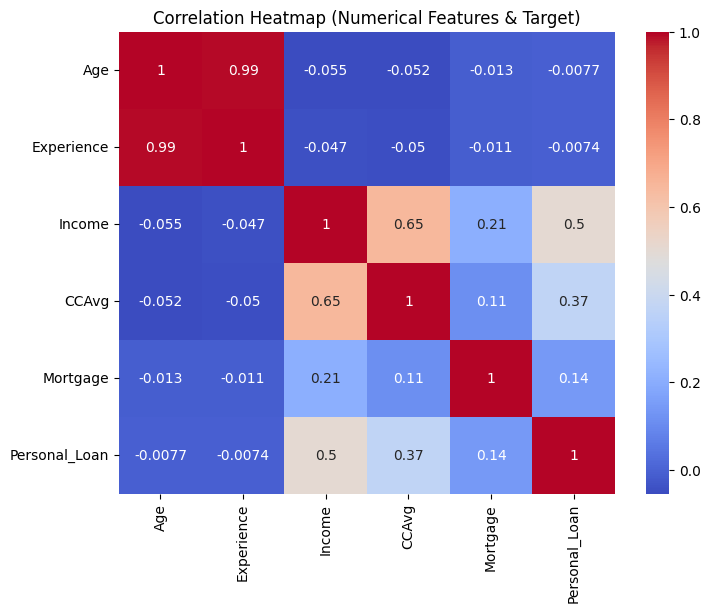

In [66]:



plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols + ['Personal_Loan']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numerical Features & Target)')
plt.show()


Bivariate analysis- Observations



1.  Experience and Age are strongly correlated
2. Age distribution is normal
3. Experience distribution is also normal
4. ZIP Codes column seem not have any relationship with Personal_Loan
5. Family and Eductaion have a relatively low correlation with Personal_Loan
6. Approximately 60% of the bank's customers use internet banking facilities offered by the bank, while 40% do not use the facility
7. Only 29% of customers use credit card facilities by other banks
8. Personal loans more opted by the customers with good credit score(Positive correlation
9. Personal loans opting is more connected with Income( positively correlated)
10. Customers with CD Account/Mortgage facility not availing the personal loans(negative correlation)



### Key Observations from EDA
Age distribution is normal as previously mentioned and with respect to target, we seem to have equal number of customers with and without personal loan across the ages of 35 to 55

Experience distribution is normal with majority of customers accepting loans having a professional experience of 10 to 30 years

Similalry we have an equal number of customers with professional experience of 10 to 30 years accepting personal loans.

We observe a right skeweness on income column
We also observe more customers with incomes of 100k and above accepting personal loan than those with lower incomes.Hence more likely to take personal loan facility

Customers with family size of 2 and above are more likely to accept personal loans than those with family size of less than 2

We observe that customers with an Average Credit Card spending of 2k USD and above are more likely to accept personal loans than those with lower Average spending

Customers with education level Undergrad and above are most likely to accept personal loans

Customers with Mortgage facility are most likely to accept personal loans than those without.

We observe a weak correlation with Securities account.
Customers with CD Account tend to accept personal loan facility more than customers without

We observe an equal number of customers having or not having access to internet banking accepting and rejecting personal loans

We observe an equal number of customers with and without credit cards from other banks accepting and rejecting personal loans

From the heat map, We observe a high correlation between Age and experience
We observe a low but moderate correlation between mortgage and income
We observe no correlation between zip code and target variable personal_loan
Target variable personal loan seems to be greatly influenced by Mortgage, Education, CD account and Credit Crd spending

# **Data pre-processing**

ID Column is not required. So we are removing it
Also ZipCode does not  have any correlation  and zipcode library have set of incompatibility issues. So we are removing ZipCode Also

In [67]:
# Remove ID and ZipCode column
df.drop('ID', axis=1, inplace=True)
df.drop('ZIPCode', axis=1, inplace=True)


In [68]:
data_filtered_with_negative_values = df[df['Experience'] < 0]
display(data_filtered_with_negative_values)


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
89,25,-1,113,4,2.30,3,0,0,0,0,0,1
226,24,-1,39,2,1.70,2,0,0,0,0,0,0
315,24,-2,51,3,0.30,3,0,0,0,0,1,0
451,28,-2,48,2,1.75,3,89,0,0,0,1,0
524,24,-1,75,4,0.20,1,0,0,0,0,1,0
536,25,-1,43,3,2.40,2,176,0,0,0,1,0
540,25,-1,109,4,2.30,3,314,0,0,0,1,0
576,25,-1,48,3,0.30,3,0,0,0,0,0,1
583,24,-1,38,2,1.70,2,0,0,0,0,1,0
597,24,-2,125,2,7.20,1,0,0,1,0,0,1


In [69]:
data_filtered_with_negative_values.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,52.0,24.519231,1.475159,23.0,24.00,24.0,25.000,29.0
Experience,52.0,-1.442308,0.639039,-3.0,-2.00,-1.0,-1.000,-1.0
Income,52.0,69.942308,37.955295,12.0,40.75,65.5,86.750,150.0
Family,52.0,2.865385,0.970725,1.0,2.00,3.0,4.000,4.0
CCAvg,52.0,2.129423,1.750562,0.2,1.00,1.8,2.325,7.2
Education,52.0,2.076923,0.836570,1.0,1.00,2.0,3.000,3.0
Mortgage,52.0,43.596154,90.027068,0.0,0.00,0.0,0.000,314.0
Personal_Loan,52.0,0.000000,0.000000,0.0,0.00,0.0,0.000,0.0
Securities_Account,52.0,0.115385,0.322603,0.0,0.00,0.0,0.000,1.0
CD_Account,52.0,0.000000,0.000000,0.0,0.00,0.0,0.000,0.0


The dataset's negative experience values are within 23-29 Age group only
 By the education and age, most probably the experience was entered as negative by mistake. Thus taking the absolute values for the experience as data pre-processing task as below


In [70]:
data.loc[data['Experience']<0,'Experience']=np.abs(data['Experience'])

In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [72]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.134600,11.415189,0.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


## 3. Model building - Decision Tree
Model can make wrong predictions as:

  

*    Predicting a customer is not going to accept (0) personal loan but in reality the customer will accept - Opportinity Loss (FN)
*   Predicting a customer is going to accept (1) personal loan but in reality the customer will not accept - Loss of marketing resources (FP)


Which Loss is greater ?

Opportunity loss will be the greater loss as the bank will lose revenue and possibly the customer

How to reduce this loss i.e need to reduce False Negatives ?

The bank needs to reduce false negatives, this can be done by maximizing the Recall.

In [73]:
display(data)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [74]:
# defining the explanatory (independent) and response (dependent) variables
X = data.drop('Personal_Loan', axis=1)  # Replace 'target_column' with your actual target column name
y = data['Personal_Loan']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.988

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       895
           1       1.00      0.89      0.94       105

    accuracy                           0.99      1000
   macro avg       0.99      0.94      0.97      1000
weighted avg       0.99      0.99      0.99      1000


Confusion Matrix:
 [[895   0]
 [ 12  93]]




*   Accuracy ≈ 0.93
*   Looks Model may slightly overfit. It would be common behaviour for decision trees.




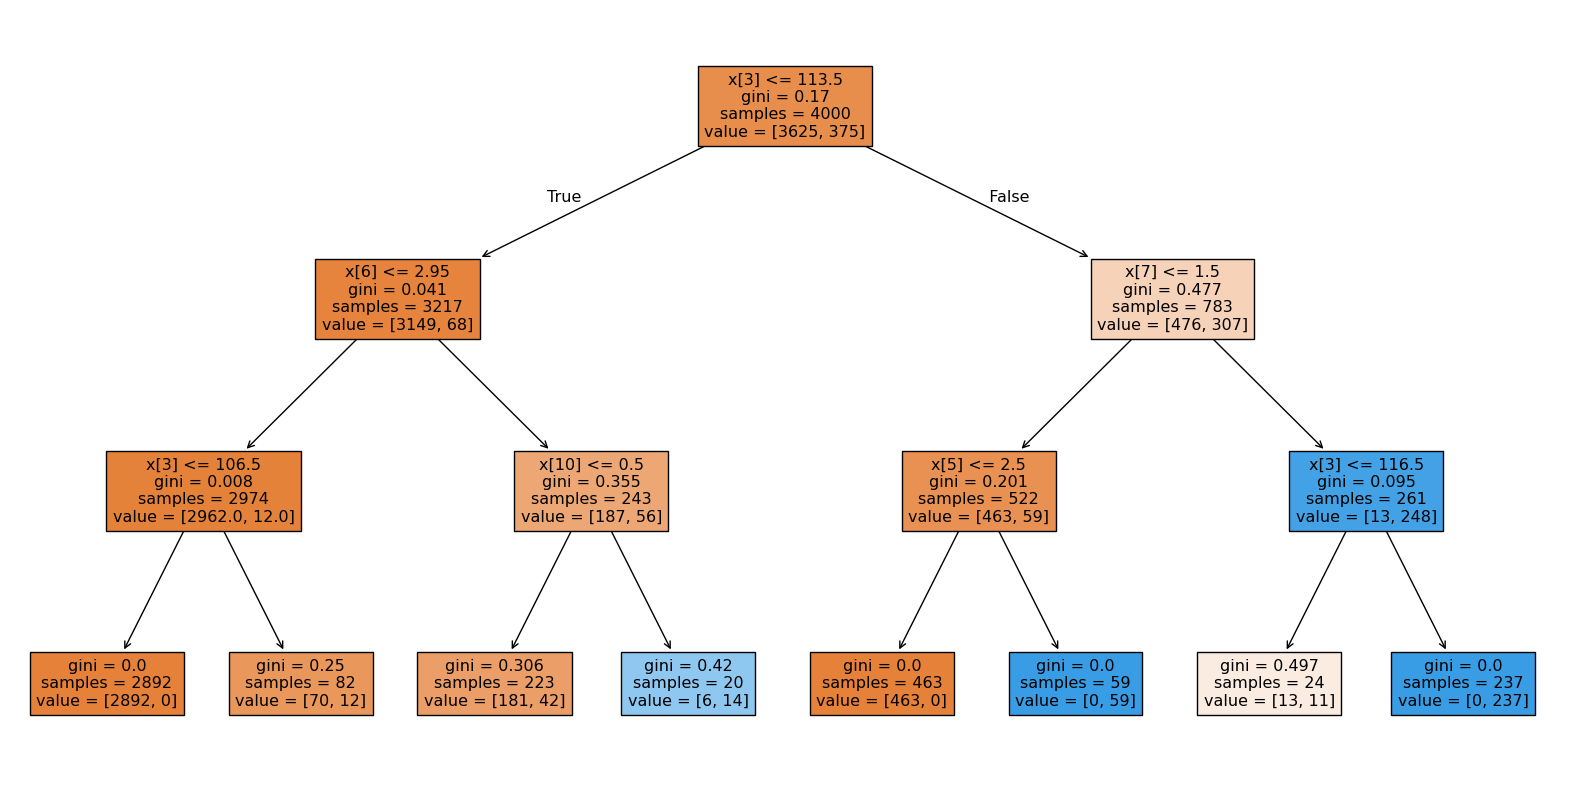

In [75]:
plt.figure(figsize=(20, 10))
plot_tree(dt, filled=True)
plt.show()

**Strengths**

High accuracy on training data (trees often overfit).

1.   Easy to interpret.
2.   Works well without feature scaling.
3.  Captures nonlinear relationships.



**Weaknesses**

1. Can overfit if depth is not restricted.

2. Less stable → small data changes may alter structure.


**To reduce overfitting:**

1. Limit max_depth

2. Set min_samples_split or min_samples_leaf

3. Use cost-complexity pruning (ccp_alpha)

# Model Performance Evaluation and Improvement


## Build Baseline Model (No Pruning)

In [76]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline model (no pruning)
baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)

# Performance
baseline_pred = baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)
print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.985


## Pre-Pruning (Early Stopping)

In [77]:
prepruned = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)
prepruned.fit(X_train, y_train)

prepruned_pred = prepruned.predict(X_test)
prepruned_acc = accuracy_score(y_test, prepruned_pred)
print("Pre-Pruned Accuracy:", prepruned_acc)

Pre-Pruned Accuracy: 0.983


## Post-Pruning (Cost Complexity Pruning)
Post-pruning first grows the full tree, then prunes using ccp_alpha.

Get the pruning path

In [78]:
path = baseline.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

In [79]:
models = []
for ccp in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp)
    model.fit(X_train, y_train)
    models.append(model)

# Evaluate each model
acc_scores = [accuracy_score(y_test, m.predict(X_test)) for m in models]

# Select best alpha
best_alpha = ccp_alphas[acc_scores.index(max(acc_scores))]
print("Best Alpha (Post-Pruning):", best_alpha)

postpruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
postpruned.fit(X_train, y_train)

postpruned_acc = max(acc_scores)
print("Post-Pruned Accuracy:", postpruned_acc)

recall = recall_score(y_test, y_pred)
print(f"Recall score: {recall}")


Best Alpha (Post-Pruning): 0.0006000000000000003
Post-Pruned Accuracy: 0.989
Recall score: 0.8857142857142857


## Comparing the Accuracies of Models( Baseline/Pre-Pruned/Post-Pruned)

In [80]:
results = pd.DataFrame({
    "Model": ["Baseline", "Pre-Pruned", "Post-Pruned"],
    "Accuracy": [baseline_acc, prepruned_acc, postpruned_acc]
})

print(results)

         Model  Accuracy
0     Baseline     0.985
1   Pre-Pruned     0.983
2  Post-Pruned     0.989


# Interpretation

1. The Baseline model typically overfits → highest training accuracy, lower test accuracy

2. The Pre-Pruned model reduces variance and improves generalization

3. The Post-Pruned model is often the best compromise

The best model is the one with highest test accuracy or best precision/recall depending on use-case.

### Choose the Final Model

Based on the evaluation, we will identify Post-Pruned model is the final model

In [81]:
best_model = postpruned

Extract Decision Rules for Final Model

In [82]:
rules = export_text(best_model, feature_names=X.columns.tolist())
print(rules)

|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Education <= 1.50
|   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Family >  3.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- Education >  1.50
|   |   |   |   |--- class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 82.50
|   |   |   |   |--- class: 0
|   |   |   |--- Income >  82.50
|   |   |   |   |--- Family <= 2.50
|   |   |   |   |   |--- Experience <= 33.50
|   |   |   |   |   |   |--- Experience <= 3.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Experience >  3.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Experience >  33.50
|   |   |   |   |   |   |--- Education <= 1.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Education >  1.50
|   |   |   |   |   |   |   |--- cla

Feature Importance on Final Model(Post-Pruned)

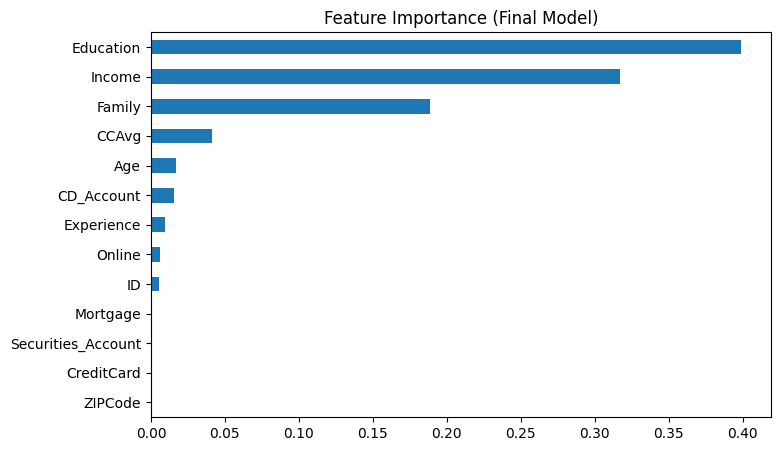

In [83]:
importances = pd.Series(best_model.feature_importances_, index=X.columns.tolist())

importances.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title("Feature Importance (Final Model)")
plt.show()

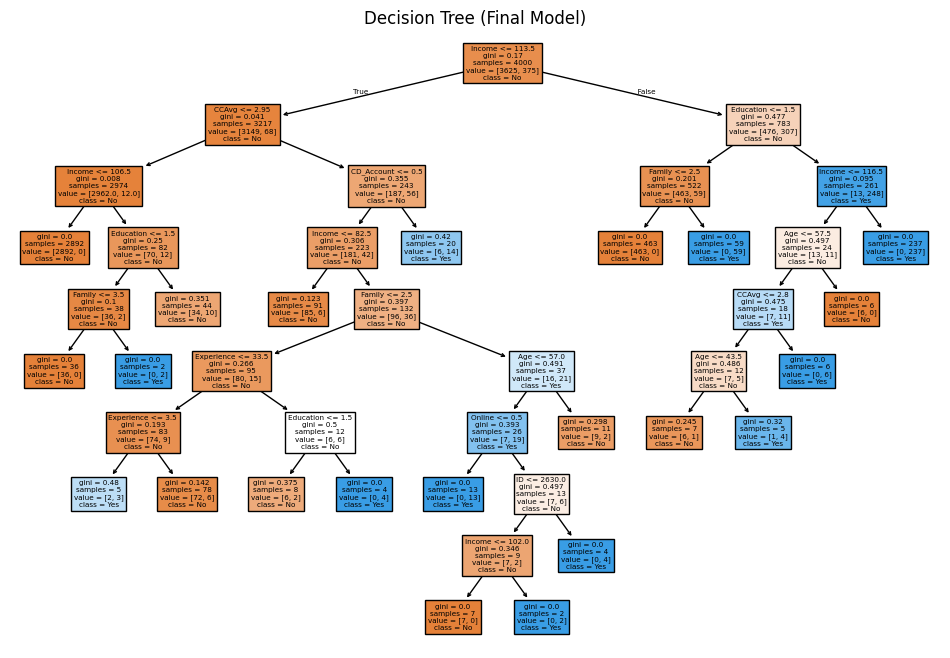

In [84]:
plt.figure(figsize=(12, 8))
plot_tree(best_model, filled=True, feature_names=X.columns.tolist(), class_names=['No', 'Yes'])
plt.title("Decision Tree (Final Model)")
plt.show()

# Actionable Insights & Recommendations




1.   The primary objective for the marketing or sales team is to avoid missing any potential opportunities. In other words, we aim to minimize the chances of predicting that a customer will not take a personal loan when, in fact, they would. This is accomplished by reducing the number of false negatives in our predictions.
2. We implemented Decision Trees with both pre-pruning and post-pruning. The post-pruning Decision Tree model delivered with Post-Pruned Accuracy: 0.989
Recall score: 0.8857142857142857
3. Decision Trees are not only easy to train but also highly interpretable, making this post pruned model will be the preferred choice.
4. According to the Decision Tree model, some of the key factors influencing a customer's likelihood of taking a personal loan include Income, having a Graduate or Advanced degree, and larger Family size.
5. Customers aged 35 - 40, with family sizes of 1 or more, and an education level of undergraduate or higher represent an ideal target for the new loan product. This segment is characterized by diverse financial needs and shows the highest likelihood of adoption.
6. Customers with mortgages above $100k are a strong target for the new loan product, as they likely need personal loans to manage high repayment installments that strain their budgets.

7. Similarly, customers with high average credit spending are potential targets, but caution is advised, as they may also carry a higher risk of default.

8. The marketing team should also consider customers with CD accounts, as these clients are lower-risk; their deposits can serve as collateral for personal loans if needed. On the other hand, customers with longer work experience are less likely to accept personal loan offers. This aligns with expectations, as they are likely approaching retirement and have minimal need for additional credit. Likewise, customers who primarily use online banking are often only interested in transactional services, making targeted loan marketing less effective for this segment.

9. High-income customers with mortgages and high CCAvg represent an attractive segment, combining low repayment risk with steady cash flow.

10. Finally, the bank should continue exploring new combinations of customer attributes to iteratively improve the predictive model and optimize marketing efforts.

